In [1]:
#Install and import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Load the dataset
#First, upload the file in Colab
df = pd.read_csv("university_student_data.csv")
print(df.head())

   Year    Term  Applications  Admitted  Enrolled  Retention Rate (%)  \
0  2015  Spring          2500      1500       600                  85   
1  2015    Fall          2500      1500       600                  85   
2  2016  Spring          2600      1550       625                  86   
3  2016    Fall          2600      1550       625                  86   
4  2017  Spring          2700      1600       650                  87   

   Student Satisfaction (%)  Engineering Enrolled  Business Enrolled  \
0                        78                   200                150   
1                        78                   200                150   
2                        79                   210                160   
3                        79                   210                160   
4                        80                   225                165   

   Arts Enrolled  Science Enrolled  
0            125               125  
1            125               125  
2            130 

In [3]:
#View general dataset information
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(20, 11)
Year                         int64
Term                        object
Applications                 int64
Admitted                     int64
Enrolled                     int64
Retention Rate (%)           int64
Student Satisfaction (%)     int64
Engineering Enrolled         int64
Business Enrolled            int64
Arts Enrolled                int64
Science Enrolled             int64
dtype: object
Year                        0
Term                        0
Applications                0
Admitted                    0
Enrolled                    0
Retention Rate (%)          0
Student Satisfaction (%)    0
Engineering Enrolled        0
Business Enrolled           0
Arts Enrolled               0
Science Enrolled            0
dtype: int64


In [4]:
#Descriptive statistics
df.describe()

,Year,Applications,Admitted,Enrolled,Retention Rate (%),Student Satisfaction (%),Engineering Enrolled,Business Enrolled,Arts Enrolled,Science Enrolled
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,2019.500000,2970.000000,1755.000000,699.000000,87.100000,82.600000,248.000000,184.500000,146.500000,120.000000
std,2.946898,322.163737,191.187425,62.903435,1.618967,3.118704,31.556132,22.763082,15.568186,8.271702
min,2015.000000,2500.000000,1500.000000,600.000000,85.000000,78.000000,200.000000,150.000000,125.000000,100.000000
25%,2017.000000,2700.000000,1600.000000,650.000000,86.000000,80.000000,225.000000,165.000000,135.000000,115.000000
50%,2019.500000,2950.000000,1725.000000,695.000000,87.000000,82.500000,245.000000,182.500000,142.500000,122.500000
75%,2022.000000,3250.000000,1900.000000,750.000000,88.000000,85.000000,275.000000,200.000000,160.000000,125.000000
max,2024.000000,3500.000000,2100.000000,800.000000,90.000000,88.000000,300.000000,225.000000,175.000000,130.000000


#Column documentation
#
# The dataset contains information about university students
# between 2015 and 2024. The columns are:
#
# - Year: academic year of the record
# - Term: semester of the year (Spring or Fall)
# - Applications: number of admission applications received
# - Admitted: number of admitted students
# - Enrolled: number of enrolled students
# - Retention Rate (%): percentage of students who did not drop out
# - Student Satisfaction (%): student satisfaction level
# - Engineering Enrolled: enrolled in Engineering
# - Business Enrolled: enrolled in Business
# - Arts Enrolled: enrolled in Arts
# - Science Enrolled: enrolled in Science

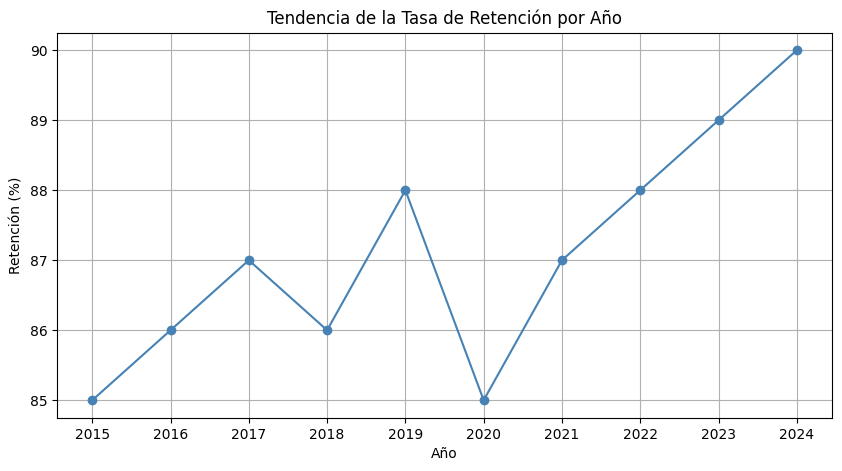

In [5]:
#Chart 1: Retention trend by year
#we use groupby to group by year and get the average
retencion = df.groupby("Year")["Retention Rate (%)"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(retencion["Year"], retencion["Retention Rate (%)"], marker="o", color="steelblue")
plt.title("Retention Rate Trend by Year")
plt.xlabel("Year")
plt.ylabel("Retention (%)")
plt.xticks(retencion["Year"])
plt.grid(True)
plt.show()

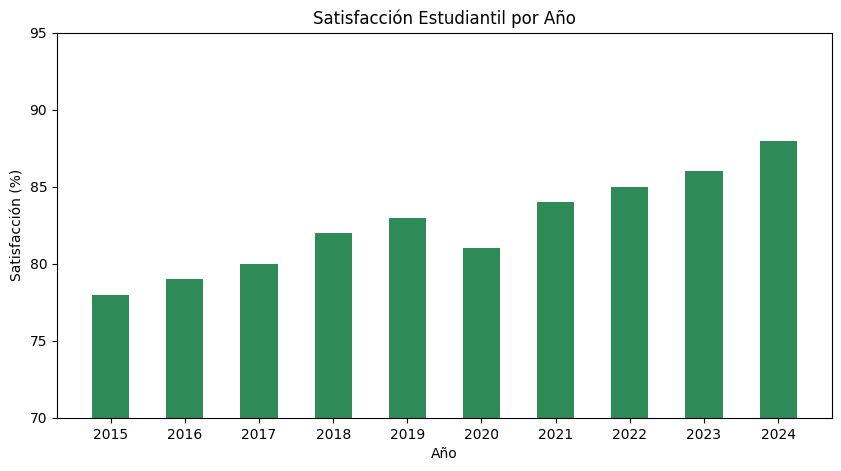

In [6]:
#Chart 2: Student satisfaction by year
#we also group by year and get the average satisfaction
satisfaccion = df.groupby("Year")["Student Satisfaction (%)"].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(satisfaccion["Year"], satisfaccion["Student Satisfaction (%)"], color="seagreen", width=0.5)
plt.title("Student Satisfaction by Year")
plt.xlabel("Year")
plt.ylabel("Satisfaction (%)")
plt.ylim(70, 95)
plt.xticks(satisfaccion["Year"])
plt.show()

     Term  Retention Rate (%)  Student Satisfaction (%)
0    Fall                87.1                      82.6
1  Spring                87.1                      82.6


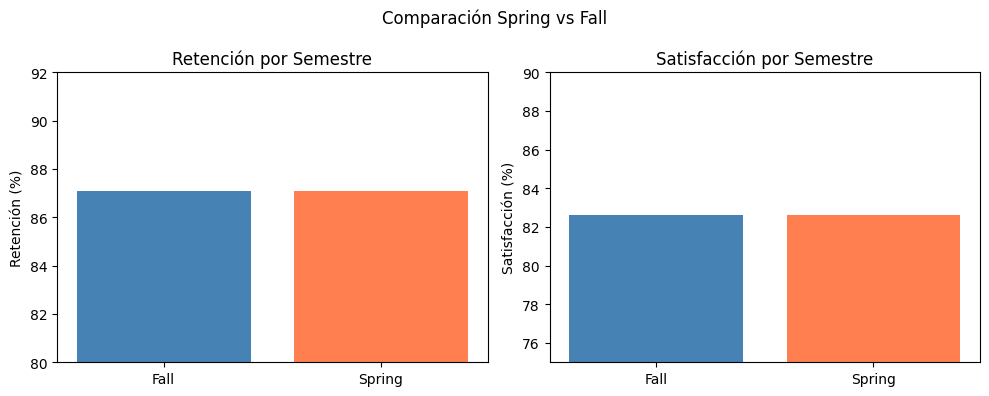

In [7]:
#Chart 3: Spring vs Fall comparison
#we group by term to compare the two main metrics
comparacion = df.groupby("Term")[["Retention Rate (%)", "Student Satisfaction (%)"]].mean().reset_index()
print(comparacion)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(comparacion["Term"], comparacion["Retention Rate (%)"], color=["steelblue", "coral"])
axes[0].set_title("Retention by Term")
axes[0].set_ylabel("Retention (%)")
axes[0].set_ylim(80, 92)

axes[1].bar(comparacion["Term"], comparacion["Student Satisfaction (%)"], color=["steelblue", "coral"])
axes[1].set_title("Satisfaction by Term")
axes[1].set_ylabel("Satisfaction (%)")
axes[1].set_ylim(75, 90)

plt.suptitle("Spring vs Fall Comparison")
plt.tight_layout()
plt.show()


In [10]:
#Extra chart: enrolled students by department using seaborn
#we use sns.lineplot to see trends across departments
depts = df.groupby("Year")[["Engineering Enrolled", "Business Enrolled",
                             "Arts Enrolled", "Science Enrolled"]].mean().reset_index()

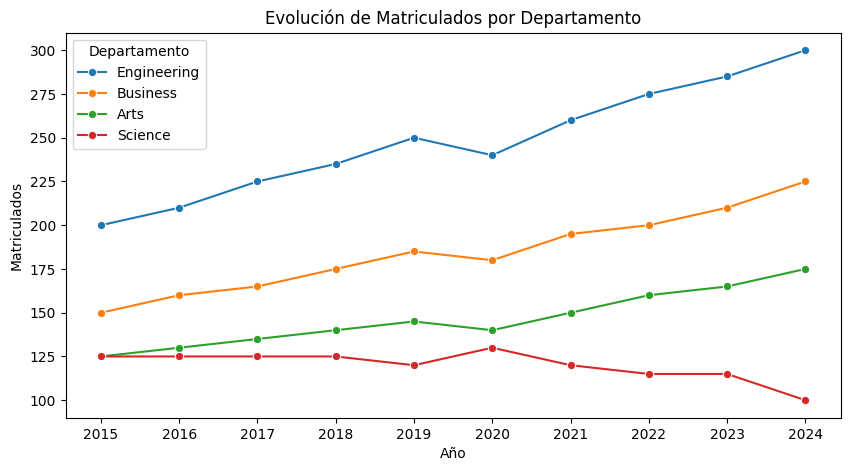

In [9]:
#convert to long format for seaborn
depts_long = depts.melt(id_vars="Year", var_name="Department", value_name="Enrolled")
depts_long["Department"] = depts_long["Department"].str.replace(" Enrolled", "")

plt.figure(figsize=(10, 5))
sns.lineplot(data=depts_long, x="Year", y="Enrolled", hue="Department", marker="o")
plt.title("Enrolled Students Evolution by Department")
plt.xlabel("Year")
plt.ylabel("Enrolled")
plt.xticks(depts["Year"])
plt.show()